# Segmentazione degli Abbonati Telecom con il Clustering k-Means

## Sintesi Esecutiva

Un operatore di telefonia mobile vuole raggruppare la propria base di abbonati postpagati in segmenti comportamentali per indirizzare offerte di fidelizzazione e dimensionare correttamente i piani dati. Questo notebook genera un dataset sintetico di utilizzo degli abbonati, quindi esegue una pipeline completa di segmentazione k-means in Base SAS: standardizza le variabili di utilizzo con **PROC STDIZE**, sceglie il numero di cluster confrontando la statistica pseudo-F tra i valori candidati di k con **PROC FASTCLUS**, adatta un modello finale ponderato con FREQ che assegna un punteggio a ogni abbonato, ed esporta i centroidi appresi in modo che lo snapshot del mese successivo possa essere valutato senza ripetere il clustering. Il risultato è una segmentazione riutilizzabile che traduce la telemetria grezza di utilizzo in un piano d'azione per la fidelizzazione.

## Origine dei Dati

**Dataset sintetico: `WORK.SUBSCRIBERS`** (100 abbonati mobili postpagati, generati inline con `call streaminit(20260531)`)

| Variabile | Tipo | Ruolo | Descrizione |
|----------|------|------|-------------|
| `cust_id` | Char | ID | Identificativo dell'abbonato (es. `SUB000123`) |
| `tenure_months` | Num | Input intervallo | Mesi di attività della linea (1-72) |
| `data_gb` | Num | Input intervallo | Utilizzo medio mensile di dati mobili, in GB |
| `voice_min` | Num | Input intervallo | Minuti voce medi mensili |
| `intl_min` | Num | Input intervallo | Minuti internazionali medi mensili |
| `support_calls` | Num | Input intervallo | Contatti di assistenza negli ultimi 90 giorni |
| `monthly_charge` | Num | Input intervallo | Fattura mensile corrente, in dollari |
| `plan_tier` | Char | Profilazione | Piano tariffario: `Base`, `Plus` o `Illimitato` |
| `n_lines` | Num | Peso FREQ | Linee sull'account |

Nel generatore sono incorporati tre profili comportamentali latenti - *light/value*, *heavy-data/streaming* e *high-touch/at-risk* - in modo che il clustering abbia una struttura reale da recuperare. Le variabili di intervallo alimentano il modello k-means; `plan_tier` viene tenuta da parte per la profilazione successiva, e `n_lines` pesa ogni account in base al suo numero di linee. Non vengono utilizzati file esterni né accesso alla rete.

## Segmentazione Comportamentale in Cinque Passaggi

Gli operatori mobili gestiscono milioni di linee postpagate, e una strategia di fidelizzazione uguale per tutti spreca margine su clienti che resterebbero comunque, mancando quelli sul punto di abbandonare. La **segmentazione comportamentale** trasforma la telemetria grezza di utilizzo in una manciata di tipologie di clienti su cui agire: utenti *light/value* sensibili al prezzo, *heavy-data streamer* che sono buoni obiettivi di upsell, e account *high-touch/at-risk* che necessitano di assistenza proattiva.

Questo notebook costruisce la segmentazione con `PROC FASTCLUS`, la procedura k-means (cluster disgiunti) di SAS. Vedremo come:

1. Generare un dataset sintetico ma realistico di utilizzo degli abbonati.
2. Portare le variabili di utilizzo su una scala comune con **PROC STDIZE**.
3. **Scegliere il numero di cluster** confrontando la statistica pseudo-F tra i valori candidati di k.
4. Adattare un modello finale ponderato con FREQ che **assegna un punteggio** a ogni abbonato e profila i segmenti.
5. **Esportare i centroidi appresi** in modo che il modello possa essere riapplicato allo snapshot del mese successivo.

## Passaggio 1 - Generare una Base di Abbonati Sintetica

Simuliamo 100 abbonati postpagati. Ognuno viene estratto da uno dei tre profili latenti con firme di utilizzo diverse, in modo che ci sia una struttura di cluster reale da recuperare. Fissiamo il flusso con `call streaminit` per la riproducibilità e limitiamo i valori simulati a intervalli plausibili con `max`/`min`/`round`.

La variabile nominale `plan_tier` è correlata con il profilo latente (gli streamer tendono verso *Illimitato*; gli utenti value verso *Base*), e `n_lines` servirà in seguito come peso FREQ in modo che gli account familiari multi-linea contino proporzionalmente.

In [1]:
DATI subscribers;
    CHIAMARE streaminit(20260531);
    LUNGHEZZA cust_id $9 plan_tier $10;
    FARE i = 1 FINO_A 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* Tre profili comportamentali latenti, prevalenza diseguale */
        u = rand('uniform');
        SE_COND u < 0.45 ALLORA profile = 1;        /* light / value        */
        ALTRIMENTI SE_COND u < 0.80 ALLORA profile = 2;   /* heavy-data streamer  */
        ALTRIMENTI profile = 3;                    /* high-touch / at-risk */

        SE_COND profile = 1 ALLORA FARE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        FINE;
        ALTRIMENTI SE_COND profile = 2 ALLORA FARE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        FINE;
        ALTRIMENTI FARE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        FINE;

        /* Livello piano correlato con il profilo */
        p = rand('uniform');
        SE_COND profile = 1 ALLORA
            plan_tier = ifc(p < 0.70, 'Base', ifc(p < 0.95, 'Plus', 'Illimitato'));
        ALTRIMENTI SE_COND profile = 2 ALLORA
            plan_tier = ifc(p < 0.65, 'Illimitato', ifc(p < 0.90, 'Plus', 'Base'));
        ALTRIMENTI
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Illimitato', 'Base'));

        /* Linee sul conto: la maggior parte ha una sola linea */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Arrotonda i valori monetari / di utilizzo a una precisione realistica */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        USCITA;
    FINE;
    RIMUOVERE i u p profile;
ESEGUIRE;

PROCEDURA STAMPARE DATI=subscribers(obs=10) noobs ETICHETTA;
    ETICHETTA cust_id="ID Abbonato" tenure_months="Anzianità (mesi)" data_gb="Dati (GB)"
          voice_min="Minuti Voce" intl_min="Minuti Internazionali"
          support_calls="Chiamate al Supporto" monthly_charge="Addebito Mensile ($)"
          plan_tier="Livello Piano" n_lines="Numero di Linee";
    TITOLO 'Campione di Record Sintetici di Utilizzo degli Abbonati';
ESEGUIRE;

                                Campione di Record Sintetici di Utilizzo degli Abbonati                                 

ID Abbonato  Livello Piano   Anzianità (mesi)  Dati (GB)  Minuti Voce  Minuti Internazionali  Chiamate al Supporto  Addebito Mensile ($)  Numero di Linee
SUB000001    Base                          15        9.7          114                      5                    11                 57.07                2
SUB000002    Base                          39        0.6          214                      2                     1                 35.88                3
SUB000003    Illimitato                    45       23.9          325                      6                     1                103.94                2
SUB000004    Base                          41        1.9          202                      1                     0                 61.69                3
SUB000005    Base                          34        2.8          112                      4                


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Passaggio 2 - Portare le Variabili su una Scala Comune

Il k-means usa la distanza euclidea, quindi una variabile di grande ampiezza come i minuti voce dominerebbe una di piccola ampiezza come le chiamate al supporto se raggruppassimo sui valori grezzi. Il rimedio standard è standardizzare prima ogni variabile di intervallo a media 0 e deviazione standard 1. **PROC STDIZE** con `METHOD=STD` fa esattamente questo, scrivendo la copia standardizzata in `WORK.SUBS_STD`. Portiamo `cust_id`, `plan_tier` e `n_lines` inalterate in modo che siano disponibili in seguito per la ponderazione e la profilazione.

In [2]:
PROCEDURA stdize DATI=subscribers out=subs_std METHOD=std;
    VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETICHETTA tenure_months="Anzianità (mesi)" data_gb="Dati (GB)" voice_min="Minuti Voce"
          intl_min="Minuti Internazionali" support_calls="Chiamate al Supporto"
          monthly_charge="Addebito Mensile ($)";
ESEGUIRE;

PROCEDURA MEDIE DATI=subs_std mean std maxdec=3;
    VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETICHETTA tenure_months="Anzianità (mesi)" data_gb="Dati (GB)" voice_min="Minuti Voce"
          intl_min="Minuti Internazionali" support_calls="Chiamate al Supporto"
          monthly_charge="Addebito Mensile ($)";
    TITOLO 'Variabili Standardizzate: Media ~ 0, Dev. Std ~ 1';
ESEGUIRE;

                                Campione di Record Sintetici di Utilizzo degli Abbonati                                 

                                   Variabili Standardizzate: Media ~ 0, Dev. Std ~ 1                                    

                                                  The MEANS Procedure

 Variable        Label                           Mean     Std Dev
 ----------------------------------------------------------------
 tenure_months   Anzianità (mesi)               0.000       1.000
 data_gb         Dati (GB)                     -0.000       1.000
 voice_min       Minuti Voce                   -0.000       1.000
 intl_min        Minuti Internazionali          0.000       1.000
 support_calls   Chiamate al Supporto          -0.000       1.000
 monthly_charge  Addebito Mensile ($)           0.000       1.000
 ----------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passaggio 3 - Quanti Segmenti? Confronto della Pseudo-F tra i k Candidati

Invece di indovinare il numero di cluster, adattiamo FASTCLUS per ciascun k candidato e leggiamo le statistiche di adattamento che riporta. La **statistica pseudo-F** (un rapporto tra varianza tra i cluster e varianza entro i cluster) e l'**R-quadrato complessivo** premiano entrambe la separazione; un buon k è quello in cui la pseudo-F è alta e l'aggiunta di un altro cluster porta rendimenti decrescenti. Un breve ciclo macro esegue k = 2, 3, 4 con `MAXITER=50` e `CONVERGE=0` (itera fino alla stabilità). Confronta le righe `Pseudo F Statistic` e `Overall R-Squared` nei tre listati seguenti: la struttura incorporata ha tre profili latenti, e k = 3 fornisce la soluzione più forte e bilanciata.

In [3]:
%macro pick_k;
    %FARE k = 2 %FINO_A 4;
        PROCEDURA FASTCLUS DATI=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            ETICHETTA tenure_months="Anzianità (mesi)" data_gb="Dati (GB)" voice_min="Minuti Voce"
                  intl_min="Minuti Internazionali" support_calls="Chiamate al Supporto"
                  monthly_charge="Addebito Mensile ($)";
            TITOLO "Numero di Cluster Candidato: k = &k";
        ESEGUIRE;
    %FINE;
%mend pick_k;
%pick_k;

                                   Variabili Standardizzate: Media ~ 0, Dev. Std ~ 1                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Passaggio 4 - Adattare la Segmentazione Finale e Assegnare un Punteggio a Ogni Abbonato

Scelto k = 3, adattiamo il modello di produzione. Questa esecuzione è pienamente idiomatica per una segmentazione operativa:

- L'istruzione `FREQ` pesa ogni account in base a `n_lines`, quindi un account familiare a quattro linee contribuisce quattro volte tanto quanto una singola linea nel calcolo dei centroidi.
- `OUT=SCORED` scrive ogni abbonato con il suo `CLUSTER` assegnato e la sua `DISTANCE` dal centroide di quel cluster; l'istruzione `ID` porta `cust_id` in quella tabella con punteggio.
- `MEAN=SEG_MEANS` cattura i centroidi per ciascun cluster (sulla scala standardizzata).
- `OUTSEED=SEG_SEEDS` salva i centroidi finali nel formato seed che FASTCLUS può rileggere - questo è il modello esportato che riapplichiamo nel Passaggio 6.

Le statistiche di adattamento del modello sono già state stabilite nella scansione del Passaggio 3, quindi qui aggiungiamo l'opzione `SHORT` per mantenere il listato concentrato sulle dimensioni dei cluster e sui centroidi che guidano l'output del punteggio.

In [4]:
PROCEDURA FASTCLUS DATI=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREQUENZE n_lines;
    id cust_id;
    ETICHETTA tenure_months="Anzianità (mesi)" data_gb="Dati (GB)" voice_min="Minuti Voce"
          intl_min="Minuti Internazionali" support_calls="Chiamate al Supporto"
          monthly_charge="Addebito Mensile ($)" cust_id="ID Abbonato" n_lines="Numero di Linee";
    TITOLO 'Segmentazione Finale: k = 3, Ponderata FREQ per Numero di Linee';
ESEGUIRE;

PROCEDURA STAMPARE DATI=seg_means noobs;
    TITOLO 'Centroidi dei Segmenti (Scala Standardizzata)';
ESEGUIRE;

                                   Variabili Standardizzate: Media ~ 0, Dev. Std ~ 1                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Passaggio 5 - Profilare i Segmenti in Unità di Business

La tabella con punteggio porta l'assegnazione `CLUSTER` di ciascun abbonato, ma sulla scala standardizzata i centroidi sono difficili da leggere. Per trasformare i numeri di cluster in personas di business, uniamo l'assegnazione alla tabella originale `subscribers` e profiliamo in unità reali - gigabyte, minuti e dollari. PROC MEANS riassume le variabili di intervallo per segmento, e PROC FREQ incrocia la `plan_tier` tenuta da parte con il segmento per mostrare il mix di piani di ciascuna persona.

                           Profili dei Segmenti: Utilizzo Medio per Cluster (Unità Originali)                           

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Anzianità (mesi)

                                         N
                            Cluster    Obs      Mean      Std Dev      Minimum      Maximum
                            ---------------------------------------------------------------
                            1           51      33.2         14.7          1.0         61.0
                            2           31      40.5         14.0         17.0         67.0
                            3           18      12.7          7.1          1.0         30.0
                            ---------------------------------------------------------------

                                        Analysis Variable : data_gb Dati (GB)

                                         N
    


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


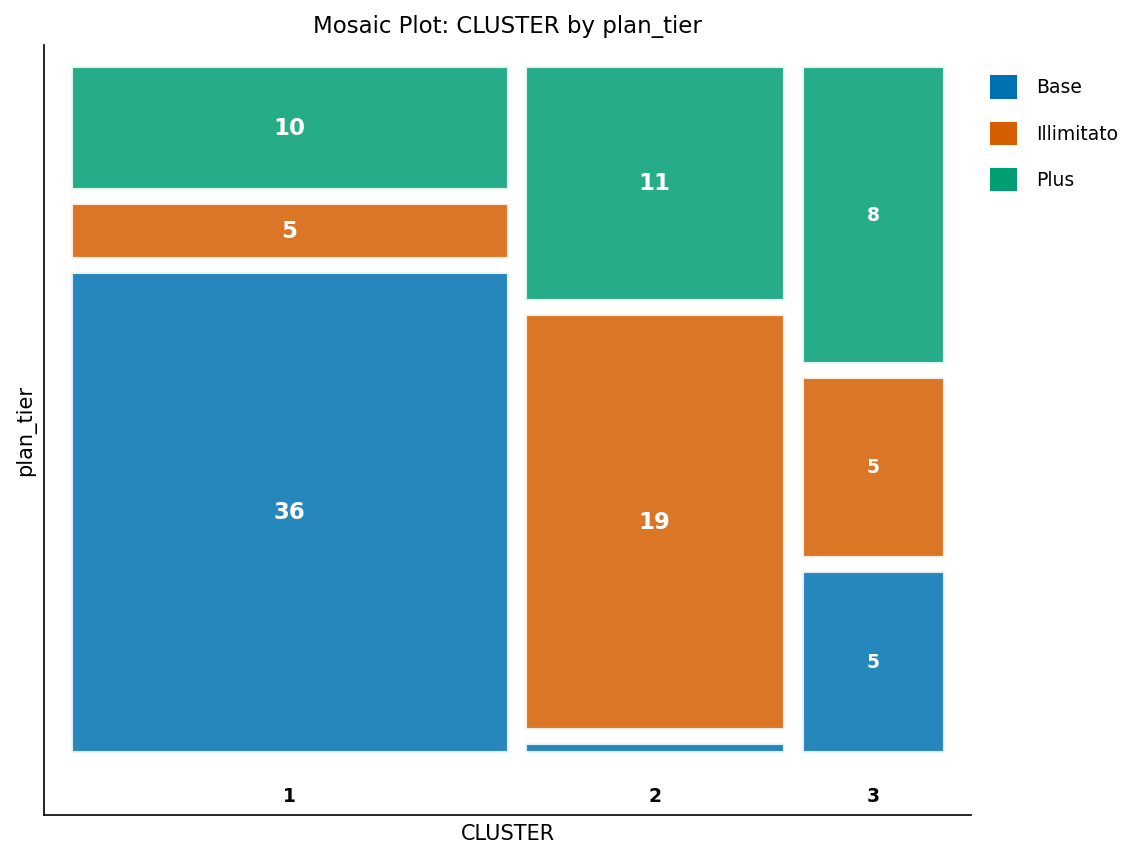

In [5]:
PROCEDURA ORDINARE DATI=scored out=scored_keys(MANTENERE=cust_id CLUSTER);
    PER cust_id;
ESEGUIRE;

PROCEDURA ORDINARE DATI=subscribers out=subs_sorted;
    PER cust_id;
ESEGUIRE;

DATI profile;
    UNIRE subs_sorted(IN=a) scored_keys(IN=b);
    PER cust_id;
    SE_COND a E_LOG b;
ESEGUIRE;

PROCEDURA MEDIE DATI=profile mean std MIN MAX maxdec=1;
    CLASSE CLUSTER;
    VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETICHETTA CLUSTER="Cluster" tenure_months="Anzianità (mesi)" data_gb="Dati (GB)"
          voice_min="Minuti Voce" intl_min="Minuti Internazionali"
          support_calls="Chiamate al Supporto" monthly_charge="Addebito Mensile ($)";
    TITOLO 'Profili dei Segmenti: Utilizzo Medio per Cluster (Unità Originali)';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    ETICHETTA CLUSTER="Cluster" plan_tier="Livello Piano";
    TITOLO 'Composizione dei Livelli di Piano in Ciascun Segmento';
ESEGUIRE;

## Passaggio 6 - Riapplicare il Modello allo Snapshot del Mese Successivo

Una segmentazione è utile solo se può essere riapplicata senza rieseguire l'intero job. I centroidi salvati in `SEG_SEEDS` nel Passaggio 4 sono un modello portabile: reintroducendoli come `SEED=SEG_SEEDS` con `MAXITER=0` si dice a FASTCLUS di *assegnare* ogni osservazione al centroide salvato più vicino senza spostare i centroidi - puro punteggio, non un nuovo adattamento. Qui riassegnamo lo stesso snapshot standardizzato per confermare che il modello esportato riproduce le assegnazioni originali; in produzione si punterebbe invece `DATA=` allo snapshot standardizzato del mese successivo.

                                 Composizione dei Livelli di Piano in Ciascun Segmento                                  


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


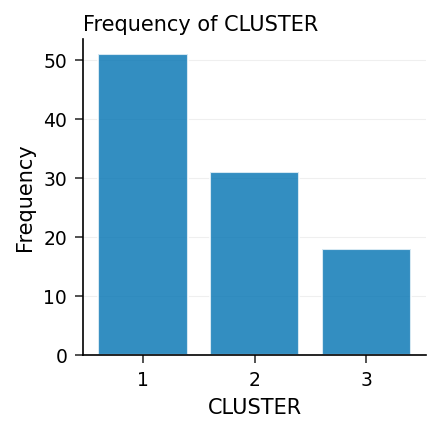

In [6]:
PROCEDURA FASTCLUS DATI=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VARIABILE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    ETICHETTA tenure_months="Anzianità (mesi)" data_gb="Dati (GB)" voice_min="Minuti Voce"
          intl_min="Minuti Internazionali" support_calls="Chiamate al Supporto"
          monthly_charge="Addebito Mensile ($)" cust_id="ID Abbonato";
    TITOLO 'Assegnazione di un Nuovo Snapshot dai Centroidi Esportati';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=rescored;
    TABLES CLUSTER / nocum;
    ETICHETTA CLUSTER="Cluster";
    TITOLO 'Abbonati Ri-Assegnati tramite il Modello Esportato';
ESEGUIRE;

## Interpretare i Risultati

FASTCLUS ha recuperato i tre segmenti comportamentali incorporati nei dati, e le tabelle di profilazione li traducono in un piano d'azione per la fidelizzazione. Leggi i numeri di segmento dalla tabella *Profili dei Segmenti* qui sopra - le etichette dei cluster sono arbitrarie, quindi identifica ciascuna persona dalla sua firma di utilizzo:

- **Utenti light / value** - pochi dati, fatture modeste, anzianità più lunga, pochissime chiamate al supporto, per lo più su *Base*. Questi clienti sono stabili e sensibili al prezzo; la mossa giusta è *proteggere il margine*, non scontare. Una raccomandazione di piano dimensionato correttamente previene lo shock da fattura senza omaggi.
- **Heavy-data streamer** - molti dati, molti minuti voce e internazionali, fatture premium, per lo più *Illimitato*. Sono fedeli e ad alto valore: la mossa è *upsell e aggiornamenti dei dispositivi*, oltre a una comunicazione proattiva sulla qualità della rete affinché la promozione di un concorrente non riesca a strapparli via.
- **High-touch / at-risk** - anzianità breve, volume elevato di chiamate al supporto, spesa di fascia media. I frequenti contatti di assistenza uniti alla bassa anzianità sono classici precursori dell'abbandono. Questo è il segmento che merita un'offerta di fidelizzazione proattiva e un follow-up di recupero del servizio.

Le scelte procedurali chiave che hanno reso questo affidabile: **PROC STDIZE** ha impedito che i minuti voce di grande ampiezza sommergessero il segnale delle chiamate al supporto; la scansione della pseudo-F ha giustificato il numero di cluster invece di indovinarlo; il peso `FREQ` ha fatto contare gli account familiari multi-linea in proporzione alla loro dimensione; e il round-trip `OUTSEED=`/`SEED=` ha esportato i centroidi in modo che il team di marketing possa risegmentare ogni snapshot mensile con una singola chiamata FASTCLUS con `MAXITER=0` - senza bisogno di un nuovo clustering.